# PTM phospho site catalog

Maps measured phosphosites in **`data.tsv`** to literature **`data/ptm.txt`** (human **PHOSPHORYLATION** rows only). **Annotated** means the `(UniProt, residue)` pair exists in the reference file — not causal for your experiment.

**Inputs:** `data.tsv`, `data/ptm.txt`. Kernel cwd: repo root or `notebooks/`.

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402
import ptm_data as ptm  # noqa: E402

DATA_PATH = ROOT / "data.tsv"
PTM_PATH = ROOT / "data" / "ptm.txt"
PPIC_PATH = ROOT / "data" / "ppic" / "edges.tsv"
KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"

THR = float(-np.log10(0.05))
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 40)

print("ROOT =", ROOT)

DATA = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)


ROOT = /Users/ph/Documents/phospho_mhg_anno


In [10]:
df_ptm = ptm.load_ptm(PTM_PATH)
df_phos = ptm.add_site_key_ptm(ptm.filter_human(ptm.filter_ptm_type(df_ptm, 'PHOSPHORYLATION')))
ptm_keys = set(df_phos['_site_key'].unique()) - {''}
data_sk = ptm.add_site_key_phospho(DATA)
data_sk['_annotated'] = data_sk['_site_key'].isin(ptm_keys)
print('Human PHOSPHORYLATION rows in ptm.txt:', len(df_phos))
print('Unique site keys in reference:', len(ptm_keys))
print('Measured sites:', len(data_sk))
print('Overall annotated fraction:', data_sk['_annotated'].mean().round(4))


Human PHOSPHORYLATION rows in ptm.txt: 119634
Unique site keys in reference: 96274
Measured sites: 2016
Overall annotated fraction: 0.6156


## Scatter: volcano per condition (color = literature annotated)

Each panel: **x = −log₁₀ p**, **y = Log2FC** for that condition; points are colored by whether the `(UniProt, residue)` appears in human **PHOSPHORYLATION** rows of `ptm.txt`. Dashed vertical line: nominal **p = 0.05**.

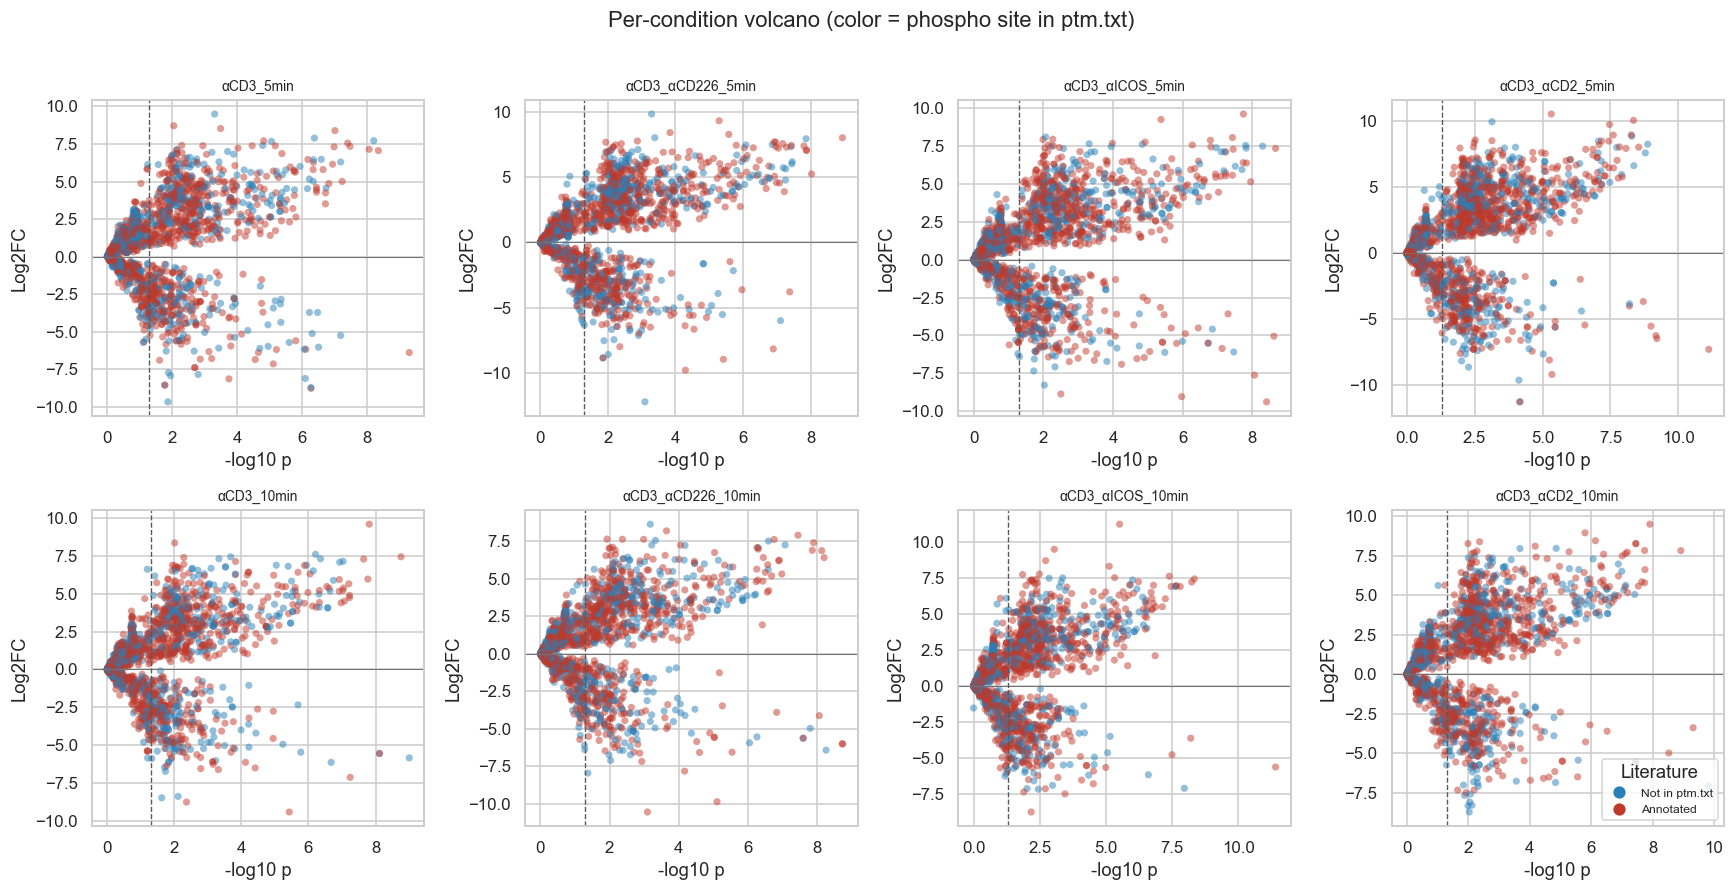

In [11]:
palette = {"Annotated": "#c0392b", "Not in ptm.txt": "#2980b9"}

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=False, sharey=False)
axes = axes.ravel()

for ax, c in zip(axes, CONDITIONS):
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors="coerce")
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors="coerce")
    tmp = data_sk.assign(_log2=log2, _nlp=nlp).dropna(subset=["_log2", "_nlp"])
    tmp["_ann_lab"] = np.where(tmp["_annotated"], "Annotated", "Not in ptm.txt")
    sns.scatterplot(
        data=tmp,
        x="_nlp",
        y="_log2",
        hue="_ann_lab",
        hue_order=["Not in ptm.txt", "Annotated"],
        palette=palette,
        ax=ax,
        alpha=0.5,
        s=22,
        edgecolor="none",
        legend=False,
        rasterized=True,
    )
    ax.axhline(0.0, color="0.45", lw=0.7)
    ax.axvline(THR, color="0.35", ls="--", lw=0.9)
    ax.set_xlabel("-log10 p")
    ax.set_ylabel("Log2FC")
    ax.set_title(c.condition_id, fontsize=9)

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=palette["Not in ptm.txt"], markersize=7, label="Not in ptm.txt"),
    plt.Line2D([0], [0], marker="o", linestyle="", color=palette["Annotated"], markersize=7, label="Annotated"),
]
axes[-1].legend(handles=handles, loc="lower right", fontsize=8, title="Literature")

fig.suptitle("Per-condition volcano (color = phospho site in ptm.txt)", y=1.01)
fig.tight_layout()
plt.show()

## Scatter: one point per measured site (combined across conditions)

**x** = maximum **−log₁₀ p** over the eight conditions; **y** = maximum **|Log2FC × (−log₁₀ p)|** (absolute signed score) over conditions — so each phosphosite is a single point. **Color** = literature annotated or not. Useful to see whether extreme sites tend to be already catalogued.

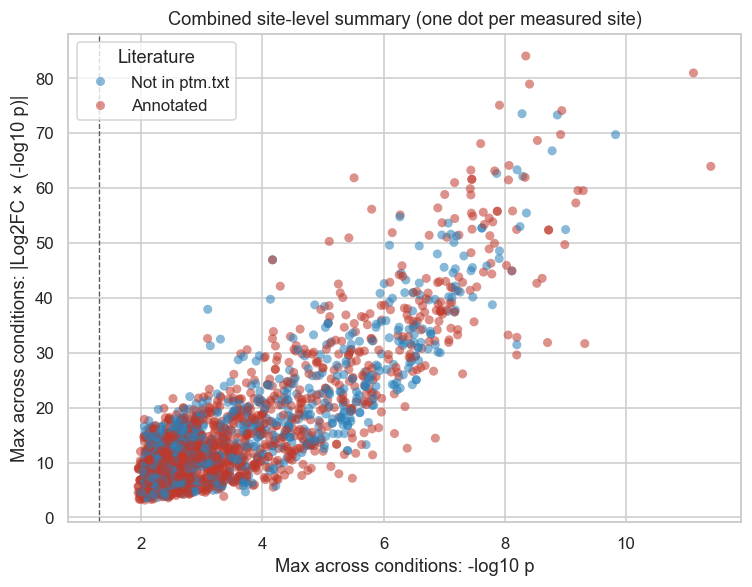

In [12]:
sc_abs = []
nlp_max = []
for c in CONDITIONS:
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors="coerce")
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors="coerce")
    signed = log2 * nlp
    sc_abs.append(signed.abs())
    nlp_max.append(nlp)

max_abs_score = pd.concat(sc_abs, axis=1).max(axis=1)
max_nlp = pd.concat(nlp_max, axis=1).max(axis=1)

sum_df = pd.DataFrame(
    {
        "max_neglog10p": max_nlp,
        "max_abs_signed_score": max_abs_score,
        "_annotated": data_sk["_annotated"].values,
    },
    index=data_sk.index,
)
sum_df["_ann_lab"] = np.where(sum_df["_annotated"], "Annotated", "Not in ptm.txt")

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(
    data=sum_df,
    x="max_neglog10p",
    y="max_abs_signed_score",
    hue="_ann_lab",
    hue_order=["Not in ptm.txt", "Annotated"],
    palette=palette,
    ax=ax,
    alpha=0.55,
    s=35,
    edgecolor="none",
    rasterized=True,
)
ax.axvline(THR, color="0.35", ls="--", lw=0.9)
ax.set_xlabel("Max across conditions: -log10 p")
ax.set_ylabel("Max across conditions: |Log2FC × (-log10 p)|")
ax.set_title("Combined site-level summary (one dot per measured site)")
ax.legend(title="Literature", loc="upper left")
fig.tight_layout()
plt.show()

## Coverage: significant sites per condition

,condition,n_sig,n_annotated,frac_annotated
0,αCD3_5min,944,606,0.641949
1,αCD3_αCD226_5min,1066,674,0.632270
2,αCD3_αICOS_5min,1064,692,0.650376
3,αCD3_αCD2_5min,1262,825,0.653724
4,αCD3_10min,901,565,0.627081
5,αCD3_αCD226_10min,874,555,0.635011
6,αCD3_αICOS_10min,984,649,0.659553
7,αCD3_αCD2_10min,1143,734,0.642170


/Users/ph/.pyenv/versions/3.12.7/lib/python3.12/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


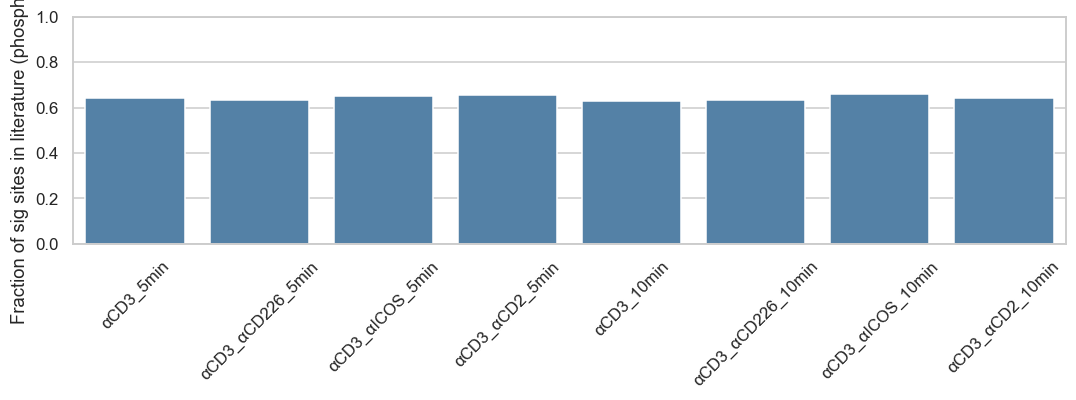

In [13]:
rows = []
for c in CONDITIONS:
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors='coerce')
    sig = (nlp >= THR) & log2.notna() & (np.abs(log2) > 0)
    sub = data_sk.loc[sig]
    n_sig = int(sig.sum())
    ann = int(sub['_annotated'].sum()) if n_sig else 0
    rows.append({
        'condition': c.condition_id,
        'n_sig': n_sig,
        'n_annotated': ann,
        'frac_annotated': (ann / n_sig) if n_sig else np.nan,
    })
cov = pd.DataFrame(rows)
display(cov)
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.barplot(data=cov, x='condition', y='frac_annotated', ax=ax, color='steelblue')
ax.set_ylabel('Fraction of sig sites in literature (phospho PTM)')
ax.set_xlabel('')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()


## |Log2FC| among significant sites: annotated vs not (pooled)

/Users/ph/.pyenv/versions/3.12.7/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/ph/.pyenv/versions/3.12.7/lib/python3.12/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/var/folders/xc/55csjjpx4mg3mrwnrdpb21pr0000gp/T/ipykernel_80665/1541497318.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not in ptm.txt', 'Annotated'])


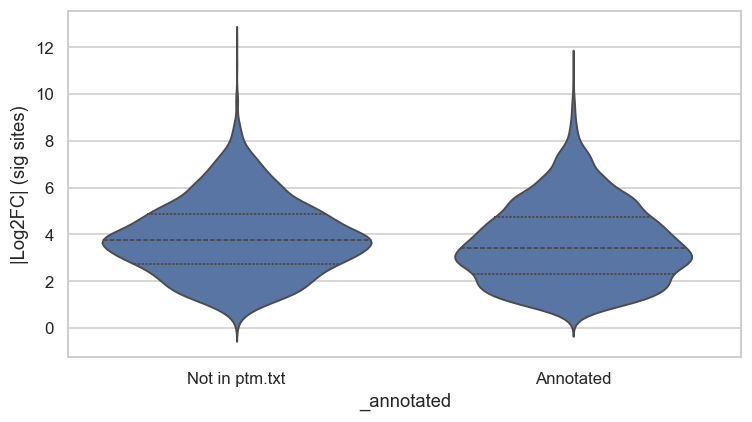

In [14]:
long_rows = []
for c in CONDITIONS:
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors='coerce')
    sig = (nlp >= THR) & log2.notna() & (np.abs(log2) > 0)
    tmp = data_sk.loc[sig, ['geneid', '_annotated']].copy()
    tmp['abs_log2'] = np.abs(log2[sig])
    tmp['condition'] = c.condition_id
    long_rows.append(tmp)
long_df = pd.concat(long_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=long_df, x='_annotated', y='abs_log2', ax=ax, inner='quart')
ax.set_xticklabels(['Not in ptm.txt', 'Annotated'])
ax.set_ylabel('|Log2FC| (sig sites)')
fig.tight_layout()
plt.show()


## Source database (among annotated significant hits)

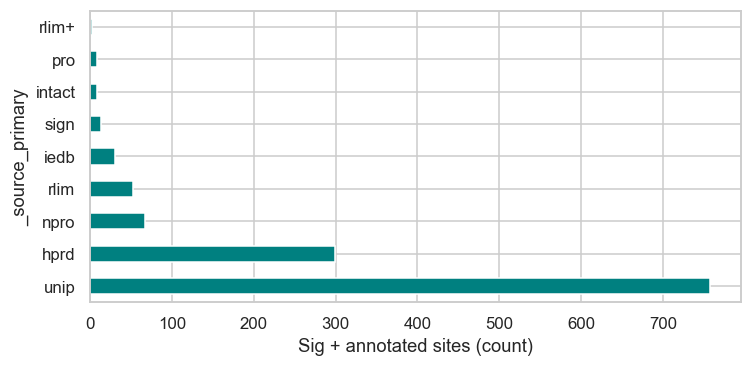

In [15]:
src_map = df_phos.groupby('_site_key')['source'].agg(lambda s: ','.join(sorted(set(map(str, s)))))
sig_any = np.zeros(len(data_sk), dtype=bool)
for c in CONDITIONS:
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors='coerce')
    sig_any |= (nlp >= THR) & log2.notna() & (np.abs(log2) > 0)
ann_sig = data_sk.loc[sig_any & data_sk['_annotated']].copy()
ann_sig['_source'] = ann_sig['_site_key'].map(src_map).fillna('')
# first source token for stacking (split multi)
ann_sig['_source_primary'] = ann_sig['_source'].str.split(',').str[0].replace('', 'unknown')
vc = ann_sig['_source_primary'].value_counts()
fig, ax = plt.subplots(figsize=(7, 3.5))
vc.head(15).plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Sig + annotated sites (count)')
fig.tight_layout()
plt.show()


## Tables: top unannotated vs annotated (by max |score| across conditions)

In [16]:
score_cols = []
for c in CONDITIONS:
    log2 = pd.to_numeric(data_sk[c.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(data_sk[c.neglogp_col], errors='coerce')
    data_sk[f'_sc_{c.condition_id}'] = (log2 * nlp).abs()
    score_cols.append(f'_sc_{c.condition_id}')
data_sk['_max_abs_score'] = data_sk[score_cols].max(axis=1)
novel = data_sk.loc[~data_sk['_annotated']].nlargest(25, '_max_abs_score')
anno = data_sk.loc[data_sk['_annotated']].nlargest(25, '_max_abs_score')
enz = df_phos.dropna(subset=['enzyme_genename'])
enz = enz[enz['enzyme_genename'].astype(str).str.strip() != '']
enz_by = enz.groupby('_site_key')['enzyme_genename'].agg(lambda s: '|'.join(sorted(set(map(str, s)))))
anno = anno.copy()
anno['_enzymes_ptm'] = anno['_site_key'].map(enz_by)
print('Top unannotated (literature-novel sites):')
display(novel[['id', 'geneid', 'proteinid', 'hl3d', '_max_abs_score']])
print('Top annotated + enzymes when known:')
display(anno[['id', 'geneid', 'proteinid', 'hl3d', '_max_abs_score', '_enzymes_ptm']])


Top unannotated (literature-novel sites):


,id,geneid,proteinid,hl3d,_max_abs_score
750,IRF2-S339,IRF2,P14316,S339,73.521678
1285,PPP1R10-S247,PPP1R10,Q96QC0,S247,73.292810
588,FRYL-S1972,FRYL,O94915,S1972,69.714360
1857,TRIM22-S384,TRIM22,Q8IYM9,S384,66.768366
40,AGAP2-T925,AGAP2,Q99490,T925,63.318472
380,CLIP1-S348,CLIP1,P30622,S348,62.644921
111,ARHGAP25-S379,ARHGAP25,P42331,S379,62.127936
1469,RGS19-S65,RGS19,P49795,S65,55.445247
1434,RBM15-S128,RBM15,Q96T37,S128,54.747177
1240,PLCB2-S958,PLCB2,Q00722,S958,53.608753


Top annotated + enzymes when known:


,id,geneid,proteinid,hl3d,_max_abs_score,_enzymes_ptm
280,CBLL1-S290,CBLL1,Q75N03,S290,84.039316,NaN
34,AFF4-S487,AFF4,Q9UHB7,S487,80.957828,NaN
1415,RB1-S795,RB1,P06400,S795,78.911030,CDK4|CDK6|PRKCB
1653,SPINDOC-S308,SPINDOC,Q9BUA3,S308,75.080118,NaN
1288,PPP1R12A-S507,PPP1R12A,O14974,S507,74.086760,NaN
1655,SPN-S291,SPN,P16150,S291,69.733245,NaN
1364,RAB3GAP1-S537,RAB3GAP1,Q15042,S537,68.653060,NaN
1037,MYH9-S1916,MYH9,P35579,S1916,68.084865,NaN
1352,PUM2-S587,PUM2,Q8TB72,S587,64.107824,NaN
713,HOOK3-S707,HOOK3,Q86VS8,S707,63.936621,NaN
